In [1]:
import jax
import jax.numpy as jnp
import optax
import flax.linen as nn
from flax.training import train_state
from flax.linen import initializers
from flax.training.common_utils import onehot
from flax.training import checkpoints
from flax import jax_utils
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import math
from itertools import islice, cycle
from flax.training.train_state import TrainState
from flax import struct
from typing import Union, Callable
from optax import tree_utils as otu

import sys
import os

# Add the parent directory of precond_gd to the Python path
# sys.path.append(os.path.abspath(os.path.join(os.path.expanduser('~'), 'precond-gd')))
relative_path = os.path.join('..', '..')  # Go up two levels to reach precond-gd
sys.path.append(os.path.abspath(relative_path))

from precond_gd.utils import datasets

# jax.config.update("jax_enable_x64", True)
# jax.config.update('jax_default_matmul_precision', 'highest')

# import json
import pickle
import orbax
from flax.training import checkpoints


# MNIST Grokking 

We want to show that MNIST groks with some parameter and AdamW, but applying the different preconditioners it reduces the distances

## Data and model definition

We import the MNIST dataset and create the necessary generators and model structures; this doesn't change in the structure

In [2]:
# Don't use TFDS because SSL sometimes is dumb on site; use Jax loader instead
# https://github.com/jax-ml/jax/blob/main/examples/datasets.py

train_images, train_labels, test_images, test_labels = datasets.mnist()
train_images, train_labels, test_images, test_labels = jnp.array(train_images), jnp.array(train_labels), jnp.array(test_images), jnp.array(test_labels)

# np.random.seed(0)
# Create a generator that yields shuffled batches of data without repetition until an epoch is complete
def data_generator(images, labels, batch_size):
    num_samples = images.shape[0]
    # while True:
    #     # Shuffle the data at the beginning of each epoch
    indices = np.random.permutation(num_samples)
    # indices = np.arange(num_samples)
    for start_idx in range(0, num_samples, batch_size):
        end_idx = min(start_idx + batch_size, num_samples)
        batch_indices = indices[start_idx:end_idx]
        yield {'image': images[batch_indices], 'label': labels[batch_indices]}

In [3]:

# Model definition (Linen)
class MLP(nn.Module):
    depth: int
    width: int

    @nn.compact
    def __call__(self, x):
        for i in range(self.depth):
            if i == 0:
                x = nn.Dense(self.width,
                             dtype=jnp.float64,
                             kernel_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(784), maxval=1 / jnp.sqrt(784)),
                             bias_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(784), maxval=1 / jnp.sqrt(784))
                            )(x)
            elif i == self.depth - 1:
                x = nn.Dense(10, 
                             dtype=jnp.float64,
                            kernel_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(200), maxval=1 / jnp.sqrt(200)),
                            bias_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(200), maxval=1 / jnp.sqrt(200))
                                )(x)
            else:
                x = nn.Dense(self.width, 
                             dtype=jnp.float64,
                            kernel_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(200), maxval=1 / jnp.sqrt(200)),
                            bias_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(200), maxval=1 / jnp.sqrt(200))
                            )(x)
            if i < self.depth - 1:
                x = nn.relu(x)
        return x



## Jax data structures

WE use a subclassed TrainState so that we can use more advanced optax transformations rather than just Adam/SGD etc. 

In [4]:

# The TrainState in Flax doesn't allow for more complex optimziers
# Thus we subclass it and insert the way we need to update 
class MyTrainState(TrainState):
    tx: optax.GradientTransformationExtraArgs = struct.field(pytree_node=False)
    def apply_gradients(self, *, grads, **kwargs):
        value, value_fn, x, labels = kwargs['value'], kwargs['value_fn'], kwargs['x'], kwargs['labels']
        updates, new_opt_state = self.tx.update(
            grads,
            self.opt_state,
            self.params,
            value=value,
            grad=grads,
            value_fn=value_fn,
            x=x,
            labels=labels
        )
        new_params_with_opt = optax.apply_updates(
            self.params, updates)
        return self.replace(
          step=self.step + 1,
          params=new_params_with_opt,
          opt_state=new_opt_state,
        )
        # print(new_params_with_opt)
    
def create_train_state(rng, model, learning_rate, weight_decay: float=1e-2, initialization_scale: float=1.0, 
                      optimizer: Union[str, optax._src.base.GradientTransformationExtraArgs] = 'adamw' ):
    params = model.init(rng, jnp.ones([1, 784], dtype=jnp.float64,))
    params = jax.tree.map(lambda p: initialization_scale * p, params)
    tx = optax.adamw(learning_rate, weight_decay=weight_decay)

    if optimizer == 'adamw':
        tx = optax.adamw(learning_rate, weight_decay=weight_decay)
    elif optimizer == 'adam':
        tx = optax.adam(learning_rate)
    elif optimizer == 'sgd':
        tx = optax.sgd(learning_rate)
    else: 
        print('Custom optimizer')
        tx = optimizer
        
    # tx = optax.chain(
    #     optax.sgd(learning_rate),
    #     optax.scale_by_backtracking_linesearch(max_backtracking_steps=5, decrease_factor=.5)
    # )
    return MyTrainState.create(apply_fn=model.apply, params=params, tx=tx)


## Parameters

These are parameters from the Omnigrok paper/Github repo. 

In [5]:
### Choose experiment parameters
train_points = 1000
optimization_steps = 100000
batch_size = 200
weight_decay = 0.01
lr = 1e-3
initialization_scale = 8.0
depth = 2             # the number of nn.Linear modules in the model
width = 250


## Training Loop

Make the training loop; we make two of them: one without any sort of precond operator, and the other with it. 
These should be transferrable; e.g. can move from one to the other using differing state

In [6]:
def train_mnist_noprecond(model, state, optimization_steps: int=100000, trian_points: int=1000, 
                          batch_size: int = 200, log_freq: int = None):
    # Logs
    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []
    log_steps = []
    losses = []
    norms = []

    @jax.jit
    def loss_fn_wrapper(params, x, labels):
        logits = model.apply(params, x)
        loss = jnp.mean((logits - labels) ** 2)
        return loss

    @jax.jit
    def batch_loss_accuracy(params, x, labels):
        # Eval model 
        logits = model.apply(params, x)
        loss = jnp.mean((logits - labels) ** 2)

        # Get accuracy 
        predicted_labels = jnp.argmax(logits, axis=1) # shape (200,)
        correct = jnp.sum(predicted_labels == labels @ jnp.arange(10)) # convert labels (50, 10) to (50,)

        return  loss, correct
        
    def compute_loss_and_accuracy(params, dataset):
        """Computes mean loss of `model` on `dataset`."""
        total_loss = 0
        total_points = 0
        correct = 0

        for batch in dataset:
            x, labels = batch['image'], batch['label']
        
            batch_loss, batch_accuracy = batch_loss_accuracy(params, x, labels)

            total_loss += batch_loss
            correct += batch_accuracy
            total_points += x.shape[0]
        return total_loss / total_points, (correct / total_points)

    # For efficiency, calculate the gradient before hand
    grad_fn = jax.value_and_grad(loss_fn_wrapper)
    test_ds = data_generator(test_images, test_images, batch_size)

    steps = 0
    break_outer = False

    if not log_freq:
        log_freq = math.ceil(optimization_steps / 150)
    with tqdm(total=optimization_steps) as pbar:
        # Loop over each epoch (approximate total number of batch steps)
        for epoch in range(optimization_steps // (train_points // batch_size) + 1):

            # Recreate the training generator for each epoch for shuffle
            train_ds = data_generator(train_images[0:train_points], train_labels[0:train_points], batch_size)
            for batch in train_ds:
                x, labels = batch['image'], batch['label']

                # Store the 
                if (steps < 15) or (steps < 150 and steps % 10 == 0) or (steps % log_freq == 0):
                    epoch_loss, epoch_acc = compute_loss_and_accuracy(
                            state.params, data_generator(train_images[0:train_points], train_labels[0:train_points], batch_size=50)
                    )
                    train_losses.append(
                        epoch_loss
                    )
                    train_accuracies.append(
                        epoch_acc
                    )
        
                    epoch_loss, epoch_acc = compute_loss_and_accuracy(
                            state.params, data_generator(test_images, test_labels, batch_size=50)
                    )
                    test_losses.append(
                        epoch_loss
                    )
                    test_accuracies.append(
                        epoch_acc
                    )
        
                    log_steps.append(steps)
                    params_leaves = jax.tree_util.tree_leaves(state.params)
                    norms.append(jnp.linalg.norm(jnp.concatenate([jnp.ravel(p) for p in params_leaves])))
                    # last_layer_norms.append(jnp.linalg.norm(state.params['Dense_2']['kernel']))
                
                loss, grads = grad_fn(state.params, x, labels)   
                losses.append(loss)
    
                state = state.apply_gradients(
                    grads=grads,
                    value=loss,
                    grad=grads,
                    value_fn=loss_fn_wrapper,
                    x=x,
                    labels=labels,
                )
                
                steps += 1
                pbar.set_description("L: {0:1.2e}|{1:1.1e}. A: {2:2.1f}%|{3:2.1f}%".format(
                        loss,
                        test_losses[-1],
                        train_accuracies[-1] * 100, 
                        test_accuracies[-1] * 100))
        
                pbar.update(1)
            if break_outer: 
                break
                
    return train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state.params, norms

def train_mnist_precond(model, state, optimization_steps: int=100000, trian_points: int=1000, batch_size: int = 200,
                        lamb:Union[float, Callable] = 5e-2, log_freq: int = None):
    # Logs
    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []
    log_steps = []
    losses = []
    norms = []

    # if lamb is a value; convert to function
    if type(lamb) == float or type(lamb) == int:
        val = lamb
        lamb = lambda b: val
    
    @jax.jit
    def loss_fn_wrapper(params, x, labels):
        logits = model.apply(params, x)
        loss = jnp.mean((logits - labels) ** 2)
        return loss

    @jax.jit
    def batch_loss_accuracy(params, x, labels):
        # Eval model 
        logits = model.apply(params, x)
        loss = jnp.mean((logits - labels) ** 2)

        # Get accuracy 
        predicted_labels = jnp.argmax(logits, axis=1) # shape (200,)
        correct = jnp.sum(predicted_labels == labels @ jnp.arange(10)) # convert labels (50, 10) to (50,)

        return  loss, correct
        
    def compute_loss_and_accuracy(params, dataset):
        """Computes mean loss of `model` on `dataset`."""
        total_loss = 0
        total_points = 0
        correct = 0

        for batch in dataset:
            x, labels = batch['image'], batch['label']
        
            batch_loss, batch_accuracy = batch_loss_accuracy(params, x, labels)

            total_loss += batch_loss
            correct += batch_accuracy
            total_points += x.shape[0]
        return total_loss / total_points, (correct / total_points)
        
    @jax.jit
    def modify_grads(grads, state, x, lamb):
        # Calculates Jacobian of 
        _, jvp_output = jax.jvp(lambda p: state.apply_fn(p, x), (state.params,), (grads,))
        jacobian_fn = jax.jacrev(
            lambda params, x: state.apply_fn(params, x)
        )(state.params, x)
        flat_jacobian = []
        for layer in jacobian_fn['params'].values():
            for param in layer.values():
                flat_jacobian.append(param.reshape(batch_size, -1))
        jacobian_fn = jnp.concatenate(flat_jacobian, axis=1)
        mat = jacobian_fn @ jacobian_fn.T
    
        out = jnp.linalg.solve(jnp.eye(mat.shape[0]) + 1 / lamb * mat, jvp_output / (lamb ** 2))
        _, vjp_fn = jax.vjp( lambda params, x: state.apply_fn(params, x), state.params, x)
        adjustment = vjp_fn(out)[0] 
        grads = jax.tree.map(lambda a, b: 1 / lamb * a - b, grads, adjustment)
        return grads

    # For efficiency, calculate the gradient before hand
    grad_fn = jax.value_and_grad(loss_fn_wrapper)
    test_ds = data_generator(test_images, test_images, batch_size)

    steps = 0
    break_outer = False
    if not log_freq:
        log_freq = math.ceil(optimization_steps / 150)
    with tqdm(total=optimization_steps) as pbar:
        # Loop over each epoch (approximate total number of batch steps)
        for epoch in range(optimization_steps // (train_points // batch_size) + 1):

            # Recreate the training generator for each epoch for shuffle
            train_ds = data_generator(train_images[0:train_points], train_labels[0:train_points], batch_size)
            for batch in train_ds:
                x, labels = batch['image'], batch['label']

                # Store the 
                if (steps < 15) or (steps < 150 and steps % 10 == 0) or (steps % log_freq == 0):
                    epoch_loss, epoch_acc = compute_loss_and_accuracy(
                            state.params, data_generator(train_images[0:train_points], train_labels[0:train_points], batch_size=50)
                    )
                    train_losses.append(
                        epoch_loss
                    )
                    train_accuracies.append(
                        epoch_acc
                    )
        
                    epoch_loss, epoch_acc = compute_loss_and_accuracy(
                            state.params, data_generator(test_images, test_labels, batch_size=50)
                    )
                    test_losses.append(
                        epoch_loss
                    )
                    test_accuracies.append(
                        epoch_acc
                    )
        
                    log_steps.append(steps)
                    params_leaves = jax.tree_util.tree_leaves(state.params)
                    norms.append(jnp.linalg.norm(jnp.concatenate([jnp.ravel(p) for p in params_leaves])))
                    # last_layer_norms.append(jnp.linalg.norm(state.params['Dense_2']['kernel']))
                
                loss, grads = grad_fn(state.params, x, labels)   
                losses.append(loss)

                grads = modify_grads(grads, state, x, lamb(steps))
                
                state = state.apply_gradients(
                    grads=grads,
                    value=loss,
                    grad=grads,
                    value_fn=loss_fn_wrapper,
                    x=x,
                    labels=labels,
                )
                
                steps += 1
                pbar.set_description("L: {0:1.2e}|{1:1.1e}. A: {2:2.1f}%|{3:2.1f}%".format(
                        loss,
                        lamb(steps),
                        train_accuracies[-1] * 100, 
                        test_accuracies[-1] * 100))
        
                pbar.update(1)
            if break_outer: 
                break
                
    return train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state.params, norms

# Experiments 

With the above done; let's run experiments and plot/save the data

## SGD

Baseline SGD first. 

In [ ]:
# Create model

scales = [1, 2, 4, 8]
output_sgd = {}

for scale in scales: 
    rng = jax.random.PRNGKey(0)
    model = MLP(depth=depth, width=width)
    state = create_train_state(rng, model, lr * .1, weight_decay, 
                               initialization_scale=scale, optimizer='sgd')
    
    out = train_mnist_noprecond(model, state, optimization_steps=1_000_000)
    output_sgd[scale] = out

with open('saves/sgd/sgd.pkl', 'wb') as f:
    pickle.dump(output_sgd, f)

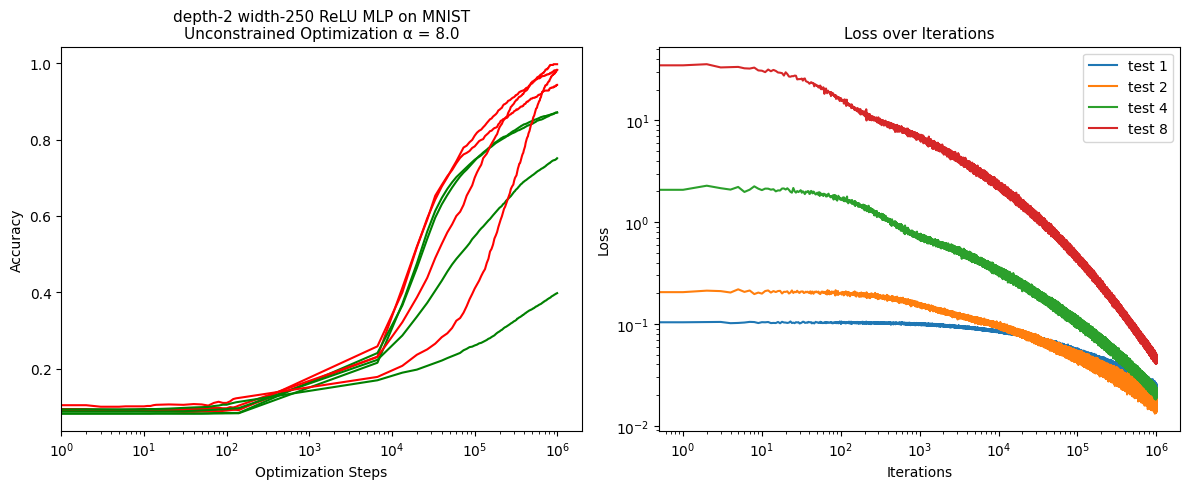

In [126]:
# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot for accuracy
for key in output_adamw.keys():
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_sgd[key]
    ax1.plot(log_steps, train_accuracies, color='red', label=f'train {key}')
    ax1.plot(log_steps, test_accuracies, color='green', label=f'test {key}')
    ax2.loglog(losses[:], label=f'test {key}')

# train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw_1
# ax1.plot(log_steps, train_accuracies, color='red', label='train')
# ax1.plot(log_steps, test_accuracies, color='green', label='test')
# ax2.loglog(losses[:])

ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
# ax1.legend(loc=(0.015, 0.75))
ax1.set_title(f"depth-2 width-250 ReLU MLP on MNIST\nUnconstrained Optimization α = {initialization_scale}", fontsize=11)

ax2.set_xlabel("Iterations")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.set_title("Loss over Iterations", fontsize=11)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

## AdamW 

First run with just AdamW for two seeds; we see the grokking behavior. Note that the losses wildly vary at the end while trying to learn features.

In [42]:
scales = [1, 2, 4, 8]
output_adamw = {}

for scale in scales: 
    rng = jax.random.PRNGKey(0)
    model = MLP(depth=depth, width=width)
    state = create_train_state(rng, model, lr, weight_decay, 
                               initialization_scale=scale, optimizer='adamw')
    
    out = train_mnist_noprecond(model, state, optimization_steps=50000)
    output_adamw[scale] = out
    

  0%|          | 0/50000 [00:00<?, ?it/s]

  0%|          | 0/50000 [00:00<?, ?it/s]

  0%|          | 0/50000 [00:00<?, ?it/s]

  0%|          | 0/50000 [00:00<?, ?it/s]

In [43]:
with open('saves/adamw/adamw.pkl', 'wb') as f:
    pickle.dump(output_adamw, f)

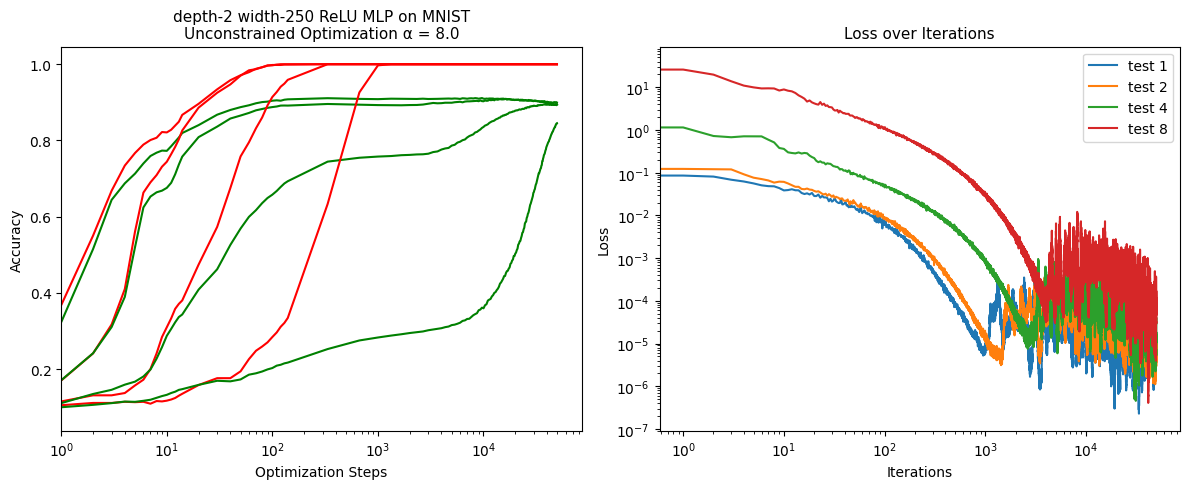

In [44]:
# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot for accuracy
for key in output_adamw.keys():
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw[key]
    ax1.plot(log_steps, train_accuracies, color='red', label=f'train {key}')
    ax1.plot(log_steps, test_accuracies, color='green', label=f'test {key}')
    ax2.loglog(losses[:], label=f'test {key}')

# train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw_1
# ax1.plot(log_steps, train_accuracies, color='red', label='train')
# ax1.plot(log_steps, test_accuracies, color='green', label='test')
# ax2.loglog(losses[:])

ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
# ax1.legend(loc=(0.015, 0.75))
ax1.set_title(f"depth-2 width-250 ReLU MLP on MNIST\nUnconstrained Optimization α = {initialization_scale}", fontsize=11)

ax2.set_xlabel("Iterations")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.set_title("Loss over Iterations", fontsize=11)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

## Pure preconditioning 

Now we run with pure preconditioning; and see the reduction in grokking; however, we note that it's HIGHLY related to the learning rate, and one can play the game for awhile. It doesn't reach as high of a test accuracy at teh end, but we can recovere that with a switch to adam. 

Story: 
- would be best if we can keep continue, but precision issues? If we exhaust the "equal/exponential for all modes" convergence, then it's dIs there anyway to test? 

In [24]:
def lamb_scale(iteration, beg=1e-2,end=1e-4, steps=500): 
    if iteration >= steps:
        return end
    else:
        # # Calculate the linear interpolation
        # scale = beg + (end - beg) * (iteration / steps)
        # return scale

        # Normalize iteration to a range of [0, 1]
        t = iteration / steps
        
        # Perform logarithmic interpolation
        scale = np.exp(np.log(beg) + t * (np.log(end) - np.log(beg)))
        return scale

# Define the piecewise learning rate schedule
schedule = optax.piecewise_interpolate_schedule('linear',
    init_value=lr * .1, boundaries_and_scales={1000: .5, 2000: .5})
schedule = optax.schedules.piecewise_constant_schedule(
    init_value=lr * 1, boundaries_and_scales={2000: lr * 50, 5000: lr * 100})
optimizer = optax.sgd(learning_rate=schedule)
optimizer = optax.sgd(learning_rate=lr * .001)

In [25]:
scales = [8]
output_pure_precond = {}

for scale in scales: 
    rng = jax.random.PRNGKey(0)
    model = MLP(depth=depth, width=width)
    state = create_train_state(rng, model, lr, weight_decay, 
                               initialization_scale=scale, optimizer=optimizer)
    
    out = train_mnist_precond(model, state, optimization_steps=100_000, lamb=lamb_scale, 
                              log_freq=500)
    output_pure_precond[scale] = out

    

Custom optimizer


/tmp/ipykernel_366415/3199608163.py:28: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in ones is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  params = model.init(rng, jnp.ones([1, 784], dtype=jnp.float64,))
/home/sjiang/precond-gd/.venv/lib/python3.13/site-packages/flax/linen/dtypes.py:79: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return [jnp.asarray(x, dtype) if x is not None else None for x in args]


  0%|          | 0/100000 [00:00<?, ?it/s]

In [87]:
with open('saves/precond/precond.pkl', 'wb') as f:
    pickle.dump(output_pure_precond, f)

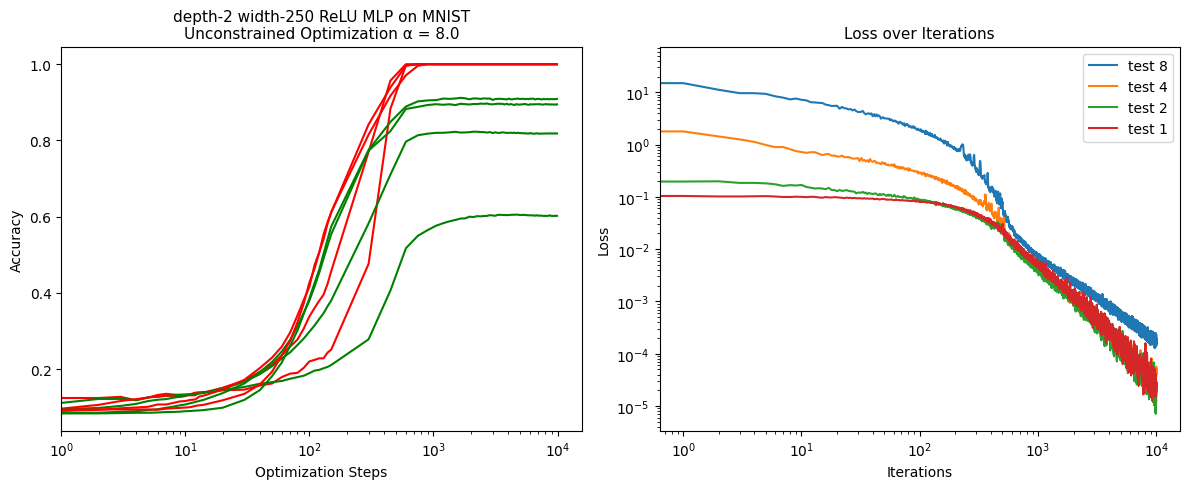

In [212]:
# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot for accuracy
for key in output_pure_precond.keys():
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_pure_precond[key]
    ax1.plot(log_steps, train_accuracies, color='red', label=f'train {key}')
    ax1.plot(log_steps, test_accuracies, color='green', label=f'test {key}')
    ax2.loglog(losses[:], label=f'test {key}')

# train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw_1
# ax1.plot(log_steps, train_accuracies, color='red', label='train')
# ax1.plot(log_steps, test_accuracies, color='green', label='test')
# ax2.loglog(losses[:])

ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
# ax1.legend(loc=(0.015, 0.75))
ax1.set_title(f"depth-2 width-250 ReLU MLP on MNIST\nUnconstrained Optimization α = {initialization_scale}", fontsize=11)

ax2.set_xlabel("Iterations")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.set_title("Loss over Iterations", fontsize=11)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

## Precond with linesearch 

Let's try to fix the above with just line search

In [98]:
def lamb_scale(iteration, beg=1e-2,end=1e-4, steps=100): 
    if iteration >= steps:
        return end
    else:
        # Calculate the linear interpolation
        scale = beg + (end - beg) * (iteration / steps)
        return scale


In [102]:
# Create model
scales = [8, 4, 2, 1]
output_ls_precond = {}

for scale in scales: 
    rng = jax.random.PRNGKey(0)
    model = MLP(depth=depth, width=width)
    tx = optax.chain(
        optax.sgd(1),
        optax.scale_by_backtracking_linesearch(max_backtracking_steps=15, decrease_factor=.5)
    )

    state = create_train_state(rng, model, lr, 
                               initialization_scale=initialization_scale, optimizer=tx)

    out = train_mnist_precond(model, state, optimization_steps=5_000, log_freq=150, lamb=1e-3)
    output_ls_precond[scale] = out



Custom optimizer


  0%|          | 0/5000 [00:00<?, ?it/s]

Custom optimizer


  0%|          | 0/5000 [00:00<?, ?it/s]

Custom optimizer


  0%|          | 0/5000 [00:00<?, ?it/s]

Custom optimizer


  0%|          | 0/5000 [00:00<?, ?it/s]

In [108]:
with open('saves/linesearch/linesearch.pkl', 'wb') as f:
    pickle.dump(output_ls_precond, f)

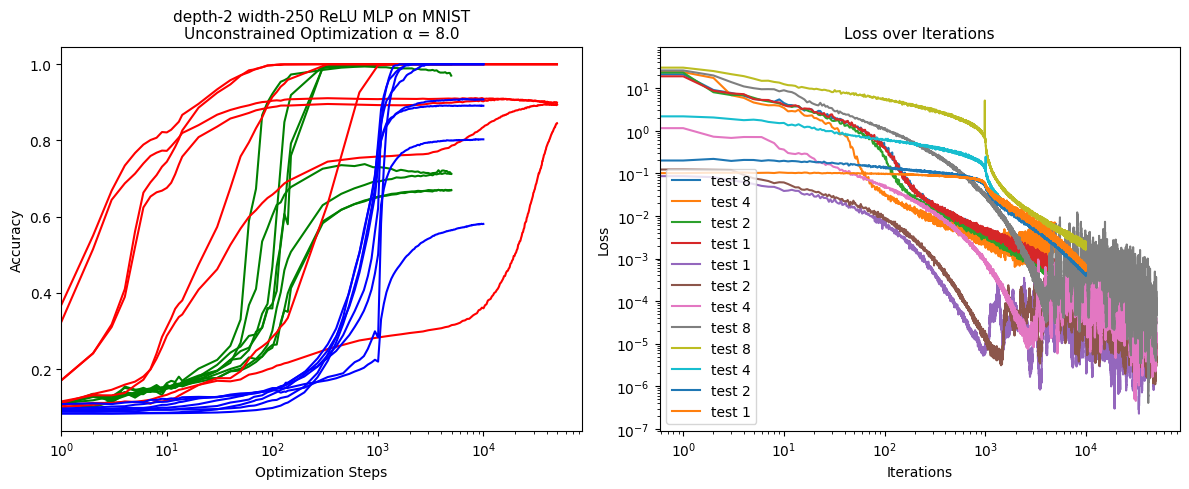

In [106]:
# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot for accuracy
for key in output_pure_precond.keys():
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_ls_precond[key]
    ax1.plot(log_steps, train_accuracies, color='green', label=f'train {key}')
    ax1.plot(log_steps, test_accuracies, color='green', label=f'test {key}')
    ax2.loglog(losses[:], label=f'test {key}')

# First subplot for accuracy
for key in output_adamw.keys():
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw[key]
    ax1.plot(log_steps, train_accuracies, color='red', label=f'train {key}')
    ax1.plot(log_steps, test_accuracies, color='red', label=f'test {key}')
    ax2.loglog(losses[:], label=f'test {key}')


for key in output_pure_precond.keys():
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_pure_precond[key]
    ax1.plot(log_steps, train_accuracies, color='blue', label=f'train {key}')
    ax1.plot(log_steps, test_accuracies, color='blue', label=f'test {key}')
    ax2.loglog(losses[:], label=f'test {key}')

# train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw_1
# ax1.plot(log_steps, train_accuracies, color='red', label='train')
# ax1.plot(log_steps, test_accuracies, color='green', label='test')
# ax2.loglog(losses[:])

ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
# ax1.legend(loc=(0.015, 0.75))
ax1.set_title(f"depth-2 width-250 ReLU MLP on MNIST\nUnconstrained Optimization α = {initialization_scale}", fontsize=11)

ax2.set_xlabel("Iterations")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.set_title("Loss over Iterations", fontsize=11)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

## Finally, can we do AdamW after to recover? 

It's interesting that the line search converegs fast, but doesn't seem to do well after; can we just run line search for a bit then do AdamW? 

In [214]:
optimizer

GradientTransformationExtraArgs(init=<function chain.<locals>.init_fn at 0x7fda283e2e80>, update=<function chain.<locals>.update_fn at 0x7fda283e2f20>)

In [ ]:
scales = [8, 4, 2, 1]
output_switch = {}

# Use parameters from pure precond above

for scale in scales: 
    rng = jax.random.PRNGKey(0)
    model = MLP(depth=depth, width=width)
    state = create_train_state(rng, model, lr, weight_decay, 
                               initialization_scale=scale, optimizer=optimizer)
    
    out_1 = train_mnist_precond(model, state, optimization_steps=2_000, lamb=lamb_scale,
                                log_freq=100)

    
    state = MyTrainState.create(
        apply_fn=model.apply,
        params=out_1[-2],
        tx=optax.adamw(lr, weight_decay=weight_decay)
    )
    # state = MyTrainState.create(
    #     apply_fn=model.apply,
    #     params=out_1[-2],
    #     tx=optax.sgd(lr * .01)
    # )

    out = train_mnist_noprecond(model, state, optimization_steps=20_000, log_freq=200)
    output_switch[scale] = (out_1, out)
    

Custom optimizer


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/20000 [00:00<?, ?it/s]

Custom optimizer


  0%|          | 0/2000 [00:00<?, ?it/s]

...

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/20000 [00:00<?, ?it/s]

Custom optimizer


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/20000 [00:00<?, ?it/s]

In [150]:
def combine_switch(first_run, second_run): 
    """
    train_losses, test_losses, train_accuracies, 
            test_accuracies, log_steps, losses, state.params, norms
    """
    combined_out = [
        first_run[0] + second_run[0], # Train losses
        first_run[1] + second_run[1], # Test losses
        first_run[2] + second_run[2], # Train acc
        first_run[3] + second_run[3], # Test acc
        jnp.concat((jnp.array(first_run[4]),
                   jnp.array(second_run[4]) +  2* first_run[4][-1] - first_run[4][-2])), # log steps (TODO)
        first_run[5] + second_run[5], # losses
        second_run[6], # Keep last params 
        first_run[7] + second_run[7] # norms
    ]

    return combined_out

In [ ]:
with open('saves/switch/switch.pkl', 'wb') as f:
    pickle.dump(output_switch, f)

In [133]:
len(output_switch[1])

2

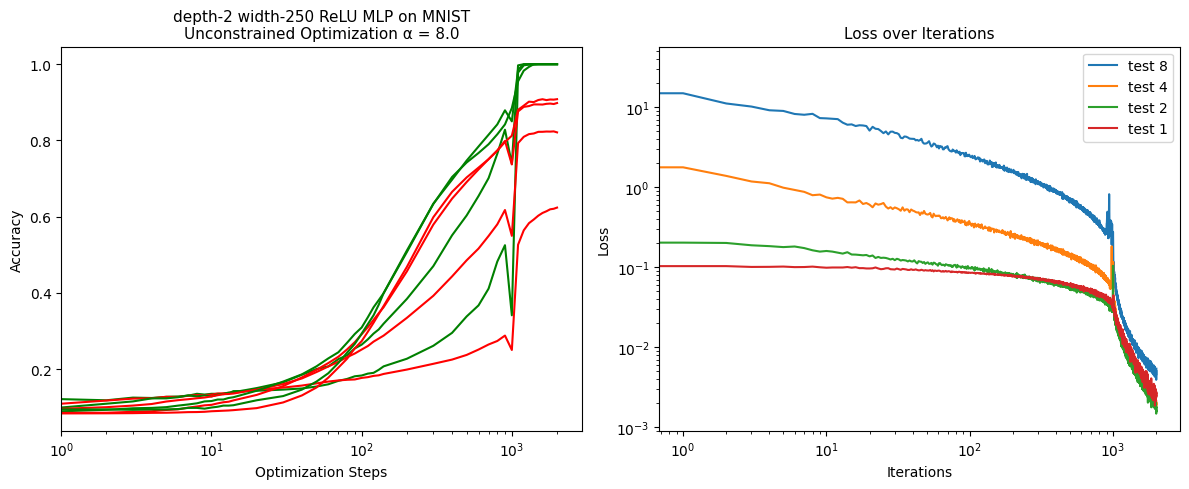

In [152]:
# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot for accuracy
for key in output_switch.keys():
    # train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = combine_switch(
    #     *output_switch[key]
    # )
    train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_switch[key][0]

    ax1.plot(log_steps, train_accuracies, color='green', label=f'train {key}')
    ax1.plot(log_steps, test_accuracies, color='red', label=f'test {key}')
    ax2.loglog(losses[:], label=f'test {key}')


# train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw_1
# ax1.plot(log_steps, train_accuracies, color='red', label='train')
# ax1.plot(log_steps, test_accuracies, color='green', label='test')
# ax2.loglog(losses[:])

ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
# ax1.legend(loc=(0.015, 0.75))
ax1.set_title(f"depth-2 width-250 ReLU MLP on MNIST\nUnconstrained Optimization α = {initialization_scale}", fontsize=11)

ax2.set_xlabel("Iterations")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.set_title("Loss over Iterations", fontsize=11)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

## Try Adam first, before LM 

This is the standard technique

In [31]:
# Create model
rng = jax.random.PRNGKey(0)
model = MLP(depth=depth, width=width)
state = create_train_state(rng, model, learning_rate=lr, 
                           initialization_scale=initialization_scale, optimizer='adamw')

output_temp = train_mnist_noprecond(model, state, optimization_steps=1_000, log_freq=100)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [32]:
state = MyTrainState.create(
    apply_fn=output_temp[-2].apply_fn,
    params=output_temp[-2].params,
    tx=optax.sgd(lr * .1))

output_temp_1 = train_mnist_precond(model, state, optimization_steps=10_000)

  0%|          | 0/10000 [00:00<?, ?it/s]

KeyboardInterrupt: 

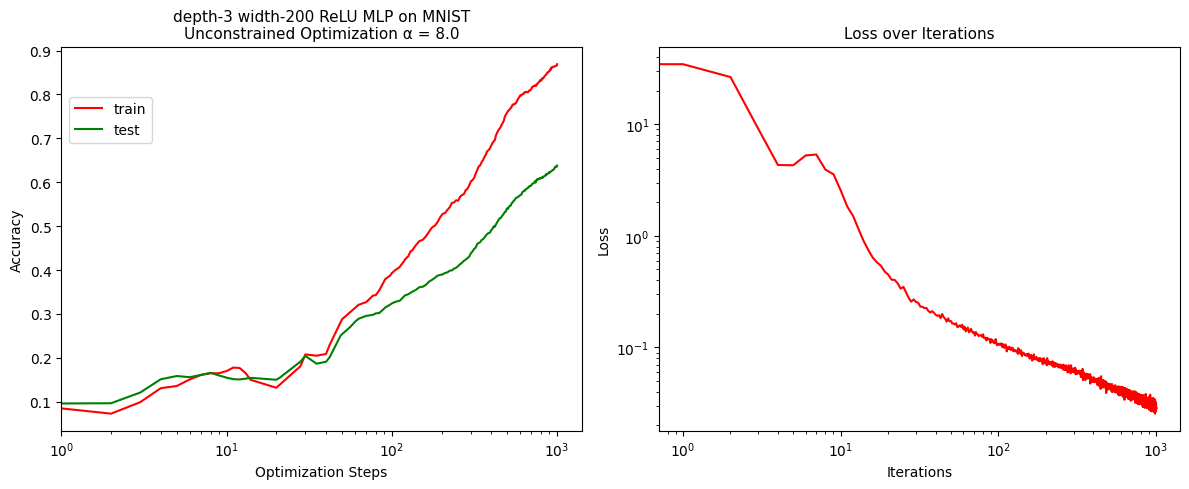

In [139]:
# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot for accuracy
train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norm = output_temp
ax1.plot(log_steps, train_accuracies, color='red', label='train')
ax1.plot(log_steps, test_accuracies, color='green', label='test')
ax2.loglog(losses[:], color='red')

# train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state = output_adamw_1
# ax1.plot(log_steps, train_accuracies, color='blue', label='train')
# ax1.plot(log_steps, test_accuracies, color='blue', label='test')
# ax2.loglog(losses[:])


# train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state = output_lm_2
# ax1.plot(log_steps, train_accuracies, color='red', label='train')
# ax1.plot(log_steps, test_accuracies, color='green', label='test')
# ax2.loglog(losses[:])

ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
ax1.legend(loc=(0.015, 0.75))
ax1.set_title(f"depth-3 width-200 ReLU MLP on MNIST\nUnconstrained Optimization α = {initialization_scale}", fontsize=11)

ax2.set_xlabel("Iterations")
ax2.set_ylabel("Loss")
ax2.set_title("Loss over Iterations", fontsize=11)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

## Seems preconditioning is very difficult to converge with SGD 

Try with line search instead? Line search seems to do pretty well; but missing that last bit of "OOMPF" on test data. 

In [ ]:
def f(x):
    if i > 300:
        return 1e-4
    else: 
        return 1e-3

In [45]:
# Create model
rng = jax.random.PRNGKey(0)
model = MLP(depth=depth, width=width)
tx = optax.chain(
    optax.sgd(1),
    optax.scale_by_backtracking_linesearch(max_backtracking_steps=15, decrease_factor=.5)
)

state = create_train_state(rng, model, lr, initialization_scale=initialization_scale, optimizer=tx)

output_lm_linesearch_1 = train_mnist_precond(model, state, optimization_steps=10_000, log_freq=150, lamb=1e-3)



Custom optimizer


  0%|          | 0/10000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [41]:
# Create model
rng = jax.random.PRNGKey(1)
model = MLP(depth=depth, width=width)
tx = optax.chain(
    optax.sgd(1),
    # optax.scale_by_backtracking_linesearch(max_backtracking_steps=15, decrease_factor=.5)
)

state = create_train_state(rng, model, lr, initialization_scale=initialization_scale, optimizer=tx)

output_lm_linesearch_2 = train_mnist_precond(model, state, optimization_steps=50_000)



Custom optimizer


  0%|          | 0/50000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot for accuracy
train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state = output_lm_linesearch_1
ax1.plot(log_steps, train_accuracies, color='green', label='train')
ax1.plot(log_steps, test_accuracies, color='green', label='test')
ax2.loglog(losses[:])

train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state = output_adamw_1
ax1.plot(log_steps, train_accuracies, color='blue', label='train')
ax1.plot(log_steps, test_accuracies, color='blue', label='test')
ax2.loglog(losses[:])


train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state = output_lm_2
ax1.plot(log_steps, train_accuracies, color='red', label='train')
ax1.plot(log_steps, test_accuracies, color='red', label='test')
ax2.loglog(losses[:])

ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
ax1.legend(loc=(0.015, 0.75))
ax1.set_title(f"depth-3 width-200 ReLU MLP on MNIST\nUnconstrained Optimization α = {initialization_scale}", fontsize=11)

ax2.set_xlabel("Iterations")
ax2.set_ylabel("Loss")
ax2.set_title("Loss over Iterations", fontsize=11)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()